Found 1992 validated image filenames belonging to 7 classes.


2026-05-04 14:37:19.607472: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2
2026-05-04 14:37:19.607620: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-05-04 14:37:19.607624: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2026-05-04 14:37:19.607908: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-05-04 14:37:19.607921: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2026-05-04 14:37:23.673352: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


125/125 ━━━━━━━━━━━━━━━━━━━━ 39s 264ms/step


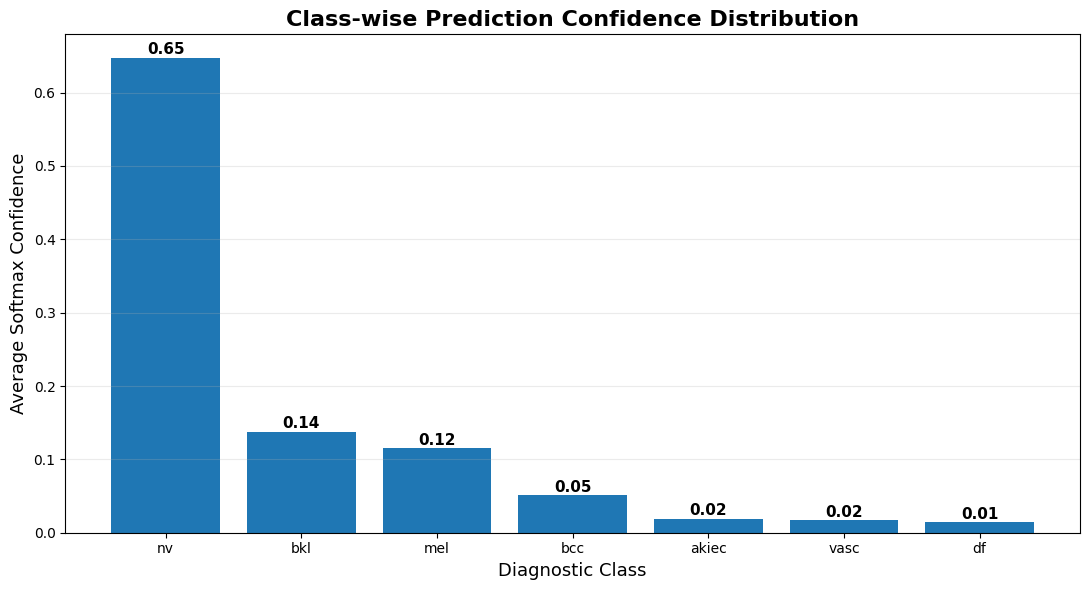

Saved: Figure_6_4_Class_Confidence.png


In [1]:
import os
from glob import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ----------------------------
# SETTINGS
# ----------------------------
IMG_SIZE = (224,224)
BATCH_SIZE = 16
VALIDATION_SPLIT = 0.2
RANDOM_STATE = 42

# ----------------------------
# LOAD DATA
# ----------------------------
BASE_DIR = os.path.abspath("..")
DATA_DIR = os.path.join(BASE_DIR, "data")
CSV_PATH = os.path.join(DATA_DIR, "HAM10000_metadata.csv")

metadata = pd.read_csv(CSV_PATH)

image_paths = {
    os.path.splitext(os.path.basename(x))[0]: x
    for x in glob(os.path.join(DATA_DIR, "HAM10000_images_part_*/*.jpg"))
}

metadata["path"] = metadata["image_id"].map(image_paths.get)
metadata = metadata.dropna()

_, val_df = train_test_split(
    metadata,
    test_size=VALIDATION_SPLIT,
    random_state=RANDOM_STATE,
    stratify=metadata["dx"]
)

# ----------------------------
# GENERATOR
# ----------------------------
val_gen = ImageDataGenerator(
    rescale=1./255
).flow_from_dataframe(
    val_df,
    x_col="path",
    y_col="dx",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

# ----------------------------
# MODEL
# ----------------------------
model = tf.keras.models.load_model(
    "../backend/skin_disease_model_v2.keras"
)

# ----------------------------
# PREDICTIONS
# ----------------------------
pred_probs = model.predict(
    val_gen,
    verbose=1
)

labels = list(val_gen.class_indices.keys())

mean_conf = pred_probs.mean(axis=0)

# sort high to low
order = np.argsort(mean_conf)[::-1]

sorted_labels = [labels[i] for i in order]
sorted_conf = mean_conf[order]

# ----------------------------
# PLOT
# ----------------------------
plt.figure(figsize=(11,6))

bars = plt.bar(
    sorted_labels,
    sorted_conf
)

plt.title(
    "Class-wise Prediction Confidence Distribution",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Diagnostic Class", fontsize=13)
plt.ylabel("Average Softmax Confidence", fontsize=13)

plt.grid(axis="y", alpha=0.25)

for bar, val in zip(bars, sorted_conf):
    plt.text(
        bar.get_x()+bar.get_width()/2,
        val+0.005,
        f"{val:.2f}",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

plt.tight_layout()

plt.savefig(
    "Figure_6_4_Class_Confidence.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: Figure_6_4_Class_Confidence.png")